In [1]:
import pandas as pd

# 读取文件
file_path = 'camera_reviews_sentiment_analysis.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 转换时间列
df['时间'] = pd.to_datetime(df['时间'])
df['年月'] = df['时间'].dt.to_period('M').astype(str)

# 计算情感净得分
df['情感净得分'] = df['positive_score'] - df['negative_score']

# 按品牌和年月分组
monthly_stats = df.groupby(['品牌', '年月']).agg({
    'positive_score': 'mean',
    'neutral_score': 'mean',
    'negative_score': 'mean',
    '情感净得分': 'mean',
    '用户ID': 'count'
}).rename(columns={'用户ID': '评论量'}).reset_index()

# 排序
monthly_stats = monthly_stats.sort_values(['品牌', '年月'])

# 表1：完整月度数据（正面、中性、负面、情感净得分、评论量）
print("="*95)
print("表1：各品牌月度情感得分完整数据")
print("="*95)
print(f"{'品牌':<6} {'年月':<12} {'正面得分':<10} {'中性得分':<10} {'负面得分':<10} {'情感净得分':<12} {'评论量':<8}")
print("-"*95)

for _, row in monthly_stats.iterrows():
    print(f"{row['品牌']:<6} {row['年月']:<12} {row['positive_score']:.4f}    {row['neutral_score']:.4f}    {row['negative_score']:.4f}    {row['情感净得分']:.4f}        {int(row['评论量']):<8}")

# 表2：各品牌每月评论量
print("\n" + "="*60)
print("表2：各品牌每月评论量")
print("="*60)
print(monthly_stats[['品牌', '年月', '评论量']].to_string(index=False))

# 表3：各品牌每月情感净得分
print("\n" + "="*60)
print("表3：各品牌每月情感净得分")
print("="*60)
print(monthly_stats[['品牌', '年月', '情感净得分']].to_string(index=False))

表1：各品牌月度情感得分完整数据
品牌     年月           正面得分       中性得分       负面得分       情感净得分        评论量     
-----------------------------------------------------------------------------------------------
佳能     2021-10      0.8921    0.0941    0.0138    0.8783        1       
佳能     2021-11      0.8921    0.0941    0.0138    0.8783        1       
佳能     2022-04      0.8921    0.0941    0.0138    0.8783        1       
佳能     2022-05      0.8921    0.0941    0.0138    0.8783        1       
佳能     2023-03      0.9931    0.0068    0.0001    0.9930        1       
佳能     2023-04      0.9329    0.0585    0.0087    0.9242        8       
佳能     2023-05      0.9172    0.0717    0.0111    0.9062        9       
佳能     2023-06      0.9324    0.0604    0.0071    0.9253        13      
佳能     2023-07      0.9107    0.0747    0.0146    0.8961        15      
佳能     2023-08      0.8843    0.1024    0.0133    0.8709        20      
佳能     2023-09      0.9566    0.0389    0.0045    0.9521        10      
佳能     20

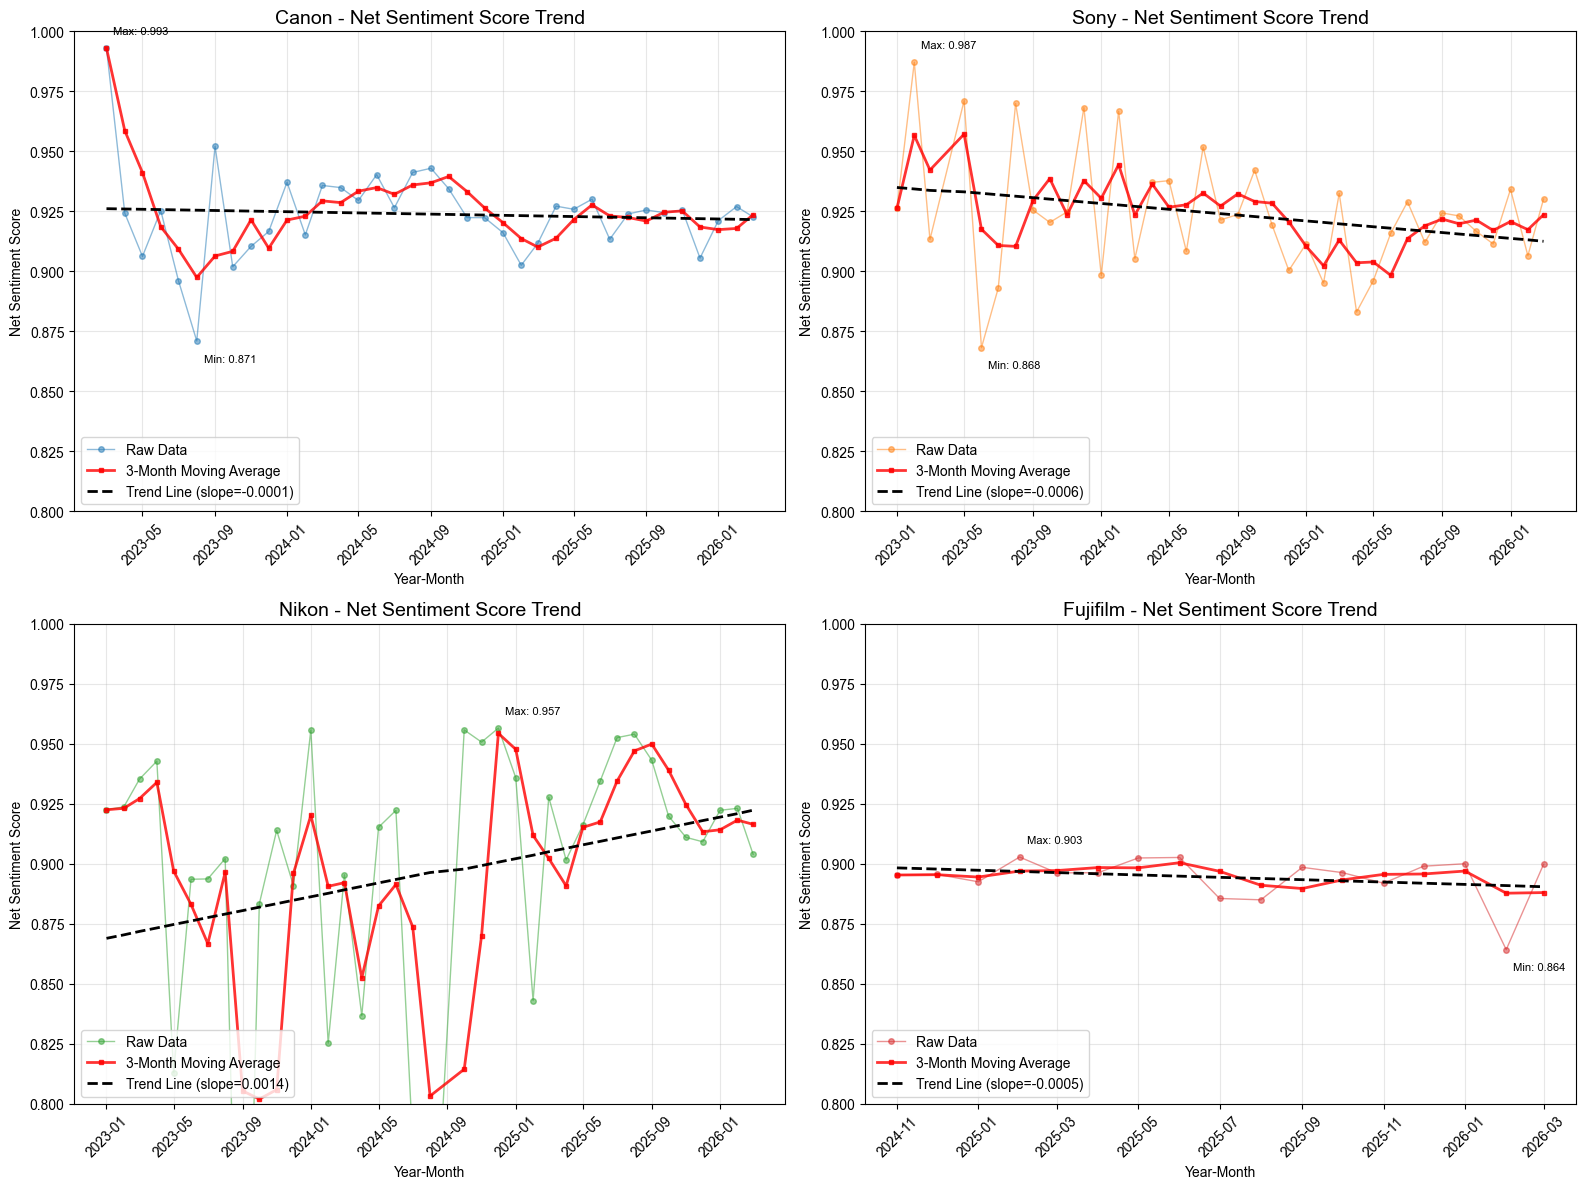

Trend chart saved as: Brand_Net_Sentiment_Trend.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set font for English display
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Read file
file_path = 'camera_reviews_sentiment_analysis.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Convert time column
df['时间'] = pd.to_datetime(df['时间'])
df['年月'] = df['时间'].dt.to_period('M').astype(str)

# Calculate net sentiment score
df['情感净得分'] = df['positive_score'] - df['negative_score']

# Group by brand and month
monthly_stats = df.groupby(['品牌', '年月']).agg({
    'positive_score': 'mean',
    'neutral_score': 'mean',
    'negative_score': 'mean',
    '情感净得分': 'mean',
    '用户ID': 'count'
}).rename(columns={'用户ID': '评论量'}).reset_index()

monthly_stats = monthly_stats.sort_values(['品牌', '年月'])

# Filter data from 2023 onwards
df_trend = monthly_stats[monthly_stats['年月'] >= '2023-01'].copy()
df_trend['年月_日期'] = pd.to_datetime(df_trend['年月'])

# ============================================================
# Plot: Net Sentiment Score Trends by Brand (Raw + Moving Average + Trend Line)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = {'佳能': '#1f77b4', '索尼': '#ff7f0e', '尼康': '#2ca02c', '富士': '#d62728'}
brand_names_en = {'佳能': 'Canon', '索尼': 'Sony', '尼康': 'Nikon', '富士': 'Fujifilm'}

for i, brand in enumerate(['佳能', '索尼', '尼康', '富士']):
    ax = axes[i]
    brand_data = df_trend[df_trend['品牌'] == brand].sort_values('年月_日期')
    brand_en = brand_names_en[brand]
    
    if len(brand_data) == 0:
        ax.text(0.5, 0.5, f'Insufficient Data for {brand_en}', ha='center', va='center')
        ax.set_title(brand_en)
        continue
    
    # Raw data
    ax.plot(brand_data['年月_日期'], brand_data['情感净得分'], 
            'o-', color=colors[brand], alpha=0.5, markersize=4, 
            label='Raw Data', linewidth=1)
    
    # Moving average
    ma3 = brand_data['情感净得分'].rolling(window=3, min_periods=1).mean()
    ax.plot(brand_data['年月_日期'], ma3, 
            's-', color='red', alpha=0.8, markersize=3, 
            label='3-Month Moving Average', linewidth=2)
    
    # Trend line
    if len(brand_data) >= 6:
        x = range(len(brand_data))
        y = brand_data['情感净得分'].values
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        trend_line = intercept + slope * np.array(x)
        ax.plot(brand_data['年月_日期'], trend_line, 
                '--', color='black', linewidth=2, 
                label=f'Trend Line (slope={slope:.4f})')
    
    # Annotate highest point
    max_idx = brand_data['情感净得分'].idxmax()
    max_point = brand_data.loc[max_idx]
    ax.annotate(f'Max: {max_point["情感净得分"]:.3f}', 
                xy=(max_point['年月_日期'], max_point['情感净得分']),
                xytext=(5, 10), textcoords='offset points', fontsize=8)
    
    # Annotate lowest point
    min_idx = brand_data['情感净得分'].idxmin()
    min_point = brand_data.loc[min_idx]
    ax.annotate(f'Min: {min_point["情感净得分"]:.3f}', 
                xy=(min_point['年月_日期'], min_point['情感净得分']),
                xytext=(5, -15), textcoords='offset points', fontsize=8)
    
    # Set title and labels
    ax.set_title(f'{brand_en} - Net Sentiment Score Trend', fontsize=14)
    ax.set_xlabel('Year-Month', fontsize=10)
    ax.set_ylabel('Net Sentiment Score', fontsize=10)
    ax.set_ylim(0.80, 1.00)
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Brand_Net_Sentiment_Trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Trend chart saved as: Brand_Net_Sentiment_Trend.png")

四个品牌ARIMA预测结果（未来3个月）

【佳能】
数据点数: 54
最佳模型: ARIMA(0, 1, 1)

未来3个月预测:
  2026-04: 0.9218  [0.8821, 0.9616]
  2026-05: 0.9218  [0.8805, 0.9631]
  2026-06: 0.9218  [0.8790, 0.9647]

最近6个月均值: 0.9210 -> 预测均值: 0.9218  (变化: +0.0008)

【索尼】
数据点数: 46
最佳模型: ARIMA(2, 0, 2)

未来3个月预测:
  2026-04: 0.9203  [0.8753, 0.9654]
  2026-05: 0.9279  [0.8817, 0.9741]
  2026-06: 0.9235  [0.8762, 0.9709]

最近6个月均值: 0.9203 -> 预测均值: 0.9239  (变化: +0.0036)

【尼康】
数据点数: 45
最佳模型: ARIMA(0, 0, 1)

未来3个月预测:
  2026-04: 0.9137  [0.8650, 0.9624]
  2026-05: 0.9181  [0.8674, 0.9689]
  2026-06: 0.9181  [0.8674, 0.9689]

最近6个月均值: 0.9149 -> 预测均值: 0.9167  (变化: +0.0018)

【富士】
数据点数: 17
最佳模型: ARIMA(0, 1, 1)

未来3个月预测:
  2026-04: 0.8942  [0.8753, 0.9131]
  2026-05: 0.8942  [0.8753, 0.9131]
  2026-06: 0.8942  [0.8753, 0.9131]

最近6个月均值: 0.8919 -> 预测均值: 0.8942  (变化: +0.0024)


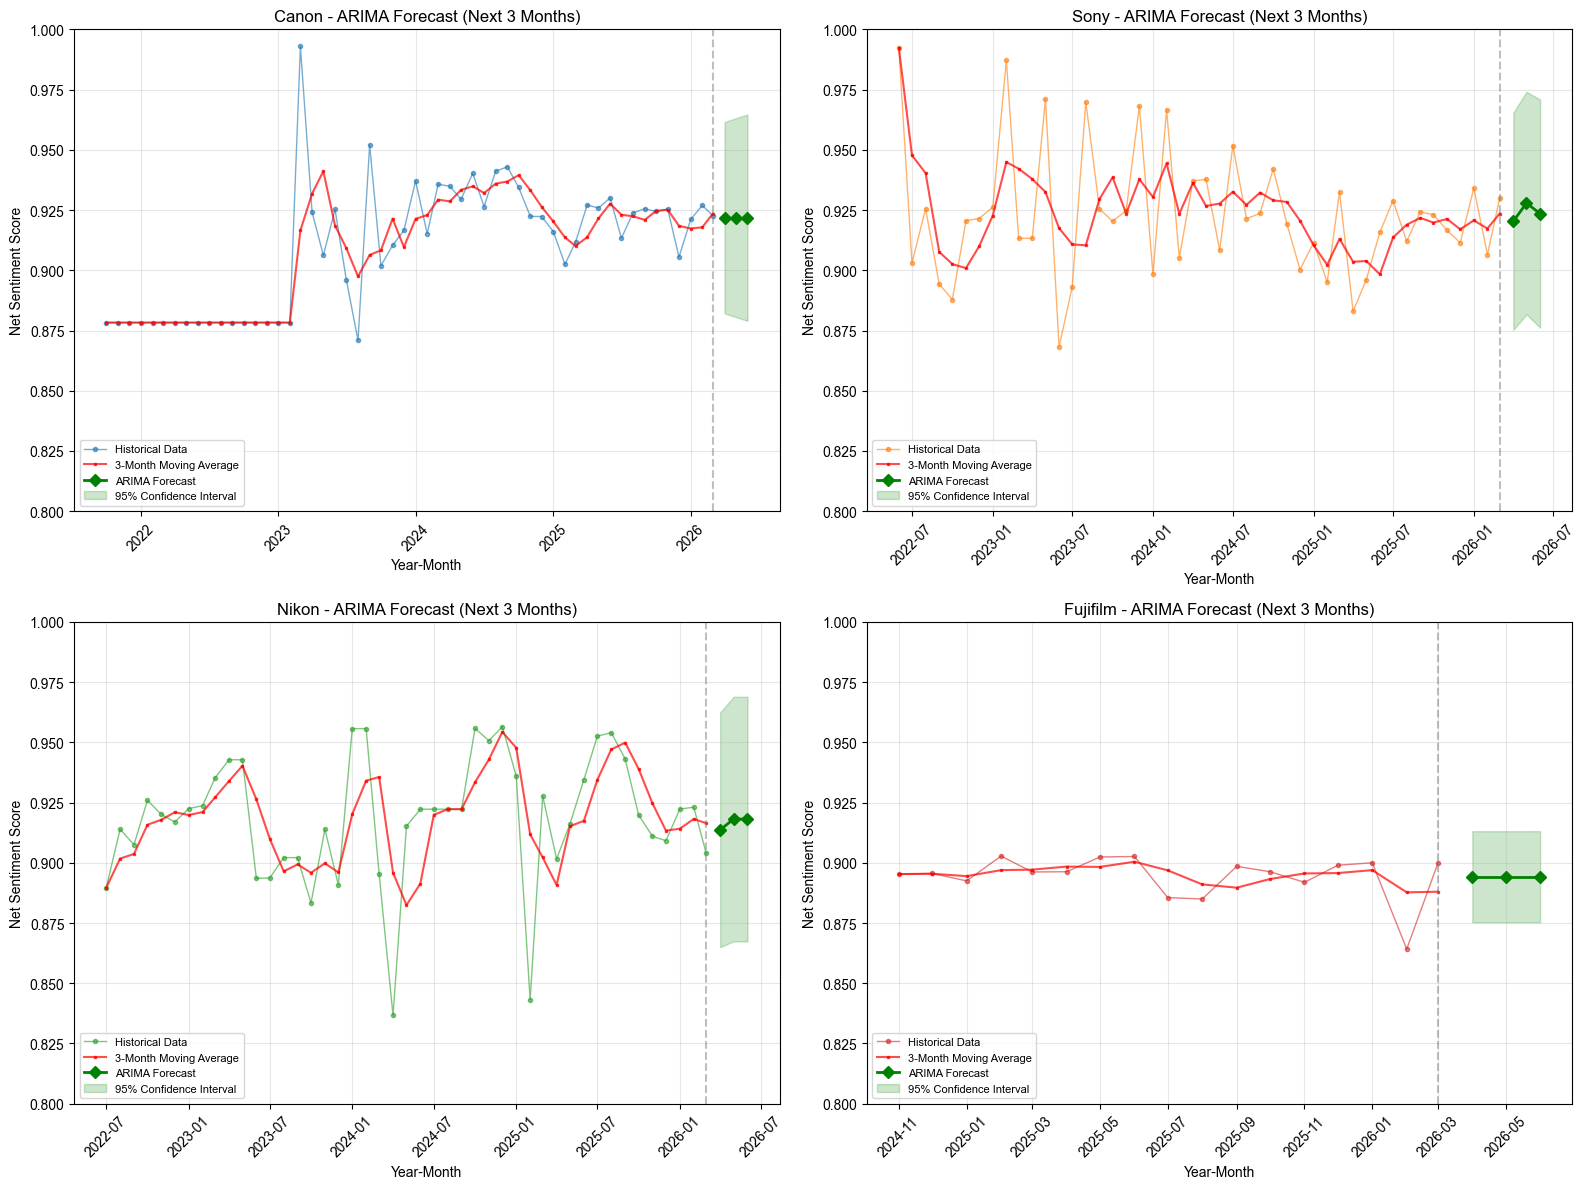


预测结果对比
品牌  数据点数           最佳模型  最近6个月均值  未来3个月预测均值     变化  置信区间宽度
佳能    54 ARIMA(0, 1, 1)   0.9210     0.9218 0.0008  0.0826
索尼    46 ARIMA(2, 0, 2)   0.9203     0.9239 0.0036  0.0924
尼康    45 ARIMA(0, 0, 1)   0.9149     0.9167 0.0018  0.1002
富士    17 ARIMA(0, 1, 1)   0.8919     0.8942 0.0024  0.0378


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 读取文件
file_path = 'camera_reviews_sentiment_analysis.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 转换时间列
df['时间'] = pd.to_datetime(df['时间'])
df['年月'] = df['时间'].dt.to_period('M').astype(str)

# 计算情感净得分
df['情感净得分'] = df['positive_score'] - df['negative_score']

# 按品牌和年月分组
monthly_stats = df.groupby(['品牌', '年月']).agg({
    '情感净得分': 'mean',
    '用户ID': 'count'
}).rename(columns={'用户ID': '评论量'}).reset_index()

monthly_stats = monthly_stats.sort_values(['品牌', '年月'])

#异常值
nikon_outliers = ['2023-05', '2023-09', '2024-02', '2024-07', '2024-08']
monthly_stats = monthly_stats[~((monthly_stats['品牌'] == '尼康') & 
                                 (monthly_stats['年月'].isin(nikon_outliers)))]

# 导入ARIMA相关库
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# 需要分析的品牌
brands = ['佳能', '索尼', '尼康', '富士']
brand_names_en = {'佳能': 'Canon', '索尼': 'Sony', '尼康': 'Nikon', '富士': 'Fujifilm'}
colors = {'佳能': '#1f77b4', '索尼': '#ff7f0e', '尼康': '#2ca02c', '富士': '#d62728'}

print("="*80)
print("四个品牌ARIMA预测结果（未来3个月）")
print("="*80)

results = []

for brand in brands:
    print(f"\n{'='*60}")
    print(f"【{brand}】")
    print(f"{'='*60}")
    
    # 提取品牌数据
    brand_data = monthly_stats[monthly_stats['品牌'] == brand].copy()
    brand_data = brand_data.sort_values('年月')
    brand_data['年月_日期'] = pd.to_datetime(brand_data['年月'])
    
    # 时间序列
    brand_ts = brand_data.set_index('年月_日期')['情感净得分']
    brand_ts = brand_ts.asfreq('MS')
    brand_ts = brand_ts.fillna(method='ffill')
    
    print(f"数据点数: {len(brand_ts)}")
    
    # 平稳性检验
    result = adfuller(brand_ts.dropna())
    if result[1] < 0.05:
        d = 0
    else:
        d = 1
    
    # 找最佳ARIMA
    best_aic = float('inf')
    best_model = None
    best_order = None
    
    for p in [0, 1, 2]:
        for q in [0, 1, 2]:
            try:
                model = ARIMA(brand_ts, order=(p, d, q))
                model_fit = model.fit()
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_model = model_fit
                    best_order = (p, d, q)
            except:
                continue
    
    print(f"最佳模型: ARIMA{best_order}")
    
    # 预测3个月
    forecast = best_model.forecast(steps=3)
    forecast_index = pd.date_range(start=brand_ts.index[-1] + pd.DateOffset(months=1), 
                                    periods=3, freq='MS')
    forecast_result = best_model.get_forecast(steps=3)
    conf_int = forecast_result.conf_int()
    
    recent_mean = brand_ts.tail(6).mean()
    forecast_mean = forecast.mean()
    
    results.append({
        '品牌': brand,
        '数据点数': len(brand_ts),
        '最佳模型': f'ARIMA{best_order}',
        '最近6个月均值': recent_mean,
        '未来3个月预测均值': forecast_mean,
        '变化': forecast_mean - recent_mean,
        '置信区间宽度': (conf_int.iloc[:, 1] - conf_int.iloc[:, 0]).mean()
    })
    
    print(f"\n未来3个月预测:")
    for i, (date, pred) in enumerate(zip(forecast_index, forecast)):
        lower = conf_int.iloc[i, 0]
        upper = conf_int.iloc[i, 1]
        print(f"  {date.strftime('%Y-%m')}: {pred:.4f}  [{lower:.4f}, {upper:.4f}]")
    
    print(f"\n最近6个月均值: {recent_mean:.4f} -> 预测均值: {forecast_mean:.4f}  (变化: {forecast_mean - recent_mean:+.4f})")

# 画图
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, brand in enumerate(brands):
    ax = axes[i]
    brand_en = brand_names_en[brand]
    
    brand_data = monthly_stats[monthly_stats['品牌'] == brand].copy()
    brand_data = brand_data.sort_values('年月')
    brand_data['年月_日期'] = pd.to_datetime(brand_data['年月'])
    
    brand_ts = brand_data.set_index('年月_日期')['情感净得分']
    brand_ts = brand_ts.asfreq('MS')
    brand_ts = brand_ts.fillna(method='ffill')
    
    # 重新拟合
    result = adfuller(brand_ts.dropna())
    d = 0 if result[1] < 0.05 else 1
    
    best_aic = float('inf')
    best_model = None
    for p in [0, 1, 2]:
        for q in [0, 1, 2]:
            try:
                model = ARIMA(brand_ts, order=(p, d, q))
                model_fit = model.fit()
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_model = model_fit
            except:
                continue
    
    forecast = best_model.forecast(steps=3)
    forecast_index = pd.date_range(start=brand_ts.index[-1] + pd.DateOffset(months=1), 
                                    periods=3, freq='MS')
    forecast_result = best_model.get_forecast(steps=3)
    conf_int = forecast_result.conf_int()
    
    ma3 = brand_ts.rolling(window=3, min_periods=1).mean()
    
    ax.plot(brand_ts.index, brand_ts.values, 'o-', color=colors[brand], alpha=0.6, markersize=3, linewidth=1, label='Historical Data')
    ax.plot(ma3.index, ma3.values, 's-', color='red', alpha=0.7, markersize=2, linewidth=1.5, label='3-Month Moving Average')
    ax.plot(forecast_index, forecast.values, 'D-', color='green', linewidth=2, markersize=6, label='ARIMA Forecast')
    ax.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='green', alpha=0.2, label='95% Confidence Interval')
    ax.axvline(x=brand_ts.index[-1], color='gray', linestyle='--', alpha=0.5)
    
    ax.set_title(f'{brand_en} - ARIMA Forecast (Next 3 Months)', fontsize=12)
    ax.set_xlabel('Year-Month', fontsize=10)
    ax.set_ylabel('Net Sentiment Score', fontsize=10)
    ax.set_ylim(0.80, 1.00)
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Four_Brands_ARIMA_Forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# 输出对比表
print("\n" + "="*80)
print("预测结果对比")
print("="*80)

result_df = pd.DataFrame(results)
print(result_df.round(4).to_string(index=False))

In [9]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np

# Assuming you already have monthly_stats data
brands = ['佳能', '索尼', '尼康', '富士']
brand_names_en = {'佳能': 'Canon', '索尼': 'Sony', '尼康': 'Nikon', '富士': 'Fujifilm'}

print("="*60)
print("ARIMA Model Validity Test")
print("="*60)

for brand in brands:
    print(f"\n【{brand_names_en[brand]}】")
    
    # Prepare data
    brand_data = monthly_stats[monthly_stats['品牌'] == brand].copy()
    brand_data = brand_data.sort_values('年月')
    brand_data['年月_日期'] = pd.to_datetime(brand_data['年月'])
    brand_ts = brand_data.set_index('年月_日期')['情感净得分']
    brand_ts = brand_ts.asfreq('MS').fillna(method='ffill')
    
    # Determine d value
    result = adfuller(brand_ts.dropna())
    d = 0 if result[1] < 0.05 else 1
    
    # Fit best model
    best_aic = float('inf')
    best_model = None
    for p in [0,1,2]:
        for q in [0,1,2]:
            try:
                model = ARIMA(brand_ts, order=(p,d,q))
                fit = model.fit()
                if fit.aic < best_aic:
                    best_aic = fit.aic
                    best_model = fit
            except:
                continue
    
    # Residual test
    residuals = best_model.resid
    lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_p = lb_test['lb_pvalue'].values[0]
    
    # Error metrics
    rmse = np.sqrt(np.mean(residuals**2))
    mae = np.mean(np.abs(residuals))
    r2 = 1 - residuals.var() / brand_ts.var()
    
    print(f"  Model: ARIMA{best_model.model.order}")
    print(f"  Residual Autocorrelation p-value: {lb_p:.4f} {'✓' if lb_p > 0.05 else '✗'}")
    print(f"  RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    
    # Conclusion
    if lb_p > 0.05:
        print(f"  ✅ Model is valid (No residual autocorrelation)")
    else:
        print(f"  ❌ Model is invalid (Residual autocorrelation exists)")

ARIMA Model Validity Test

【Canon】
  Model: ARIMA(0, 1, 1)
  Residual Autocorrelation p-value: 1.0000 ✓
  RMSE: 0.1212, MAE: 0.0260
  ✅ Model is valid (No residual autocorrelation)

【Sony】
  Model: ARIMA(2, 0, 2)
  Residual Autocorrelation p-value: 0.7762 ✓
  RMSE: 0.0242, MAE: 0.0180
  ✅ Model is valid (No residual autocorrelation)

【Nikon】
  Model: ARIMA(0, 0, 1)
  Residual Autocorrelation p-value: 0.2176 ✓
  RMSE: 0.0249, MAE: 0.0184
  ✅ Model is valid (No residual autocorrelation)

【Fujifilm】
  Model: ARIMA(0, 1, 1)
  Residual Autocorrelation p-value: 1.0000 ✓
  RMSE: 0.2174, MAE: 0.0586
  ✅ Model is valid (No residual autocorrelation)
